**ٌRahma Hamed** -
**Ali Alfadhli**-
**Shahd Derbass**












**P2**

**Dataset Used:** synthetic_personal_finance_dataset.csv   
[Kaggle Link:](https://www.kaggle.com/datasets/miadul/personal-finance-ml-dataset)  

We chose this dataset because it contains personal attributes like age, education level and gender, as well as, financial information like each individual's income, savings, loans and debts. All these factors are keys to predicting future unemployment rates for both men and woman and understanding gender inequality.

**Dataset Overview**

The project's aim is to analyze and predict weather a person is employed or not by alot of factors. We will compare female and male economic status and how factors such as age, education level and environment influences the possibility of an idividual to be unemployed. In resulting, creating fair employment policies.

In [ ]:
!pip -q install gdown

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gdown

In [ ]:
FILE_ID = "1oPwhwWmBYJWZMpDjLK6oBen6rpBnxTeC"
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", "dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv")

print("Data Type and Format: ")
print(df.info())

rows, cols = df.shape
print(f"\nRecord Count: {rows}")
print(f"Attribute Count: {cols}")

#print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1oPwhwWmBYJWZMpDjLK6oBen6rpBnxTeC
To: /content/dataset.csv
100%|██████████| 4.19M/4.19M [00:00<00:00, 166MB/s]

Data Type and Format: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  object 
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  object 
 3   education_level          32424 non-null  object 
 4   employment_status        32424 non-null  object 
 5   job_title                32424 non-null  object 
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  object 
 10  loan_type                12995 non-null  object 
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14 

The data uses a tabular structure, and the file format is csv.  
The dataset contains 32,424 records and 20 attributes.  
There are 11 numerical columns, 8 of them are float64, used for income/savings and 3 are int64, used for age/credit score.  
There are 9 categorical columns used for strings like gender, user_id etc.

**Target Variable:** 'employment_status', as the classification model can predict wether an individual will be employed, unemployed (self-employed will consider it as employed) based on his/her features.

**Useful Attributes for Prediction:**  
'gender', 'age', 'education_level', 'job_title', 'monthly_income_usd', 'debt_to_income_ratio', 'region'

**Data types**:

Numeric:
age, monthly_income_usd, monthly_expenses_usd, savings_usd, credit_score


Categorical: gender, education_level, employment_status, region, job_title



**Exploratory Data Analysis**

In [ ]:
cols = ['gender', 'education_level', 'region', 'employment_status']

for col in cols:
    print(f"Column {col}: ")
    print("Frequency counts: ", df[col].value_counts())
    print("\nLabel Porportion: ", df[col].value_counts(normalize=True))
    print("Most common value (mode): ", df[col].mode()[0])
    print("\n")

Column gender: 
Frequency counts:  gender
Male      15595
Female    15550
Other      1279
Name: count, dtype: int64

Label Porportion:  gender
Male      0.480971
Female    0.479583
Other     0.039446
Name: proportion, dtype: float64
Most common value (mode):  Male


Column education_level: 
Frequency counts:  education_level
Bachelor       13038
Master          9673
High School     6456
PhD             1638
Other           1619
Name: count, dtype: int64

Label Porportion:  education_level
Bachelor       0.402110
Master         0.298328
High School    0.199112
PhD            0.050518
Other          0.049932
Name: proportion, dtype: float64
Most common value (mode):  Bachelor


Column region: 
Frequency counts:  region
North America    6581
Asia             6551
Europe           6519
Other            6407
Africa           6366
Name: count, dtype: int64

Label Porportion:  region
North America    0.202967
Asia             0.202042
Europe           0.201055
Other            0.197601
Africa

**Univariate EDA**

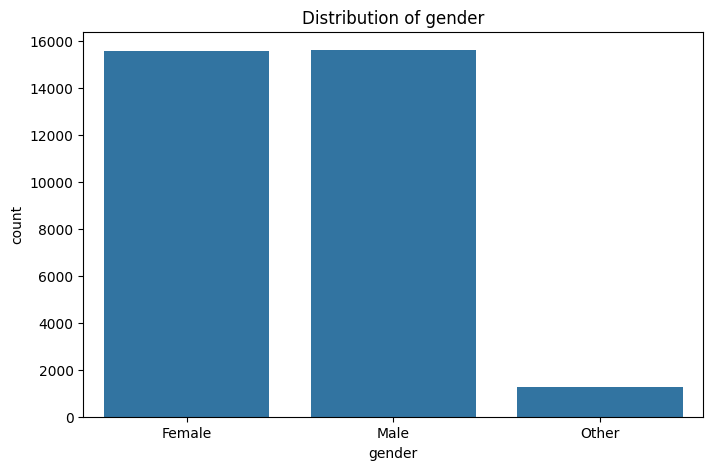

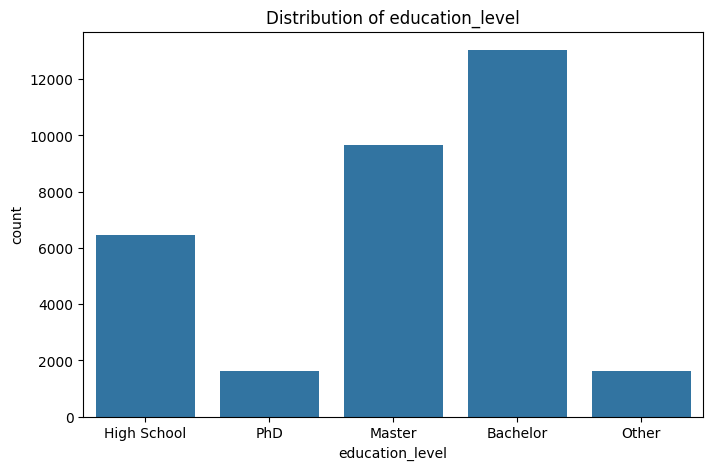

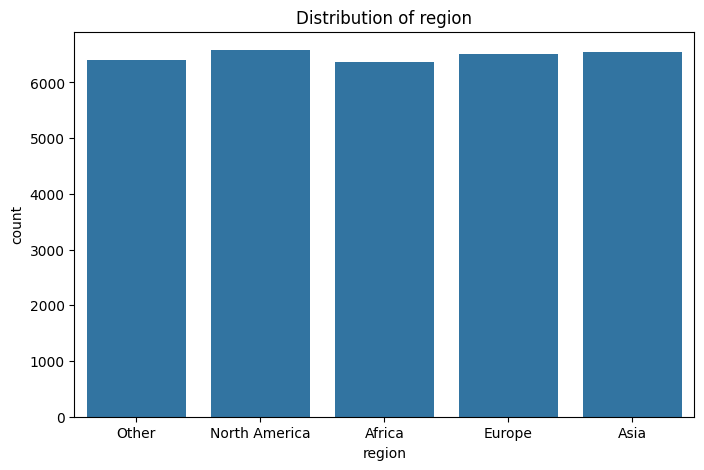

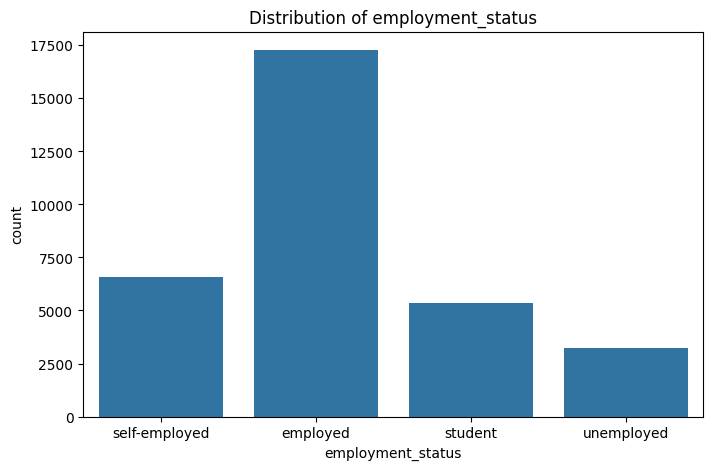

In [ ]:
cols = ['gender', 'education_level', 'region', 'employment_status']

for col in cols:
  plt.figure(figsize=(8, 5))
  sns.countplot(x=col, data=df)
  plt.title(f"Distribution of {col}")
  plt.show()

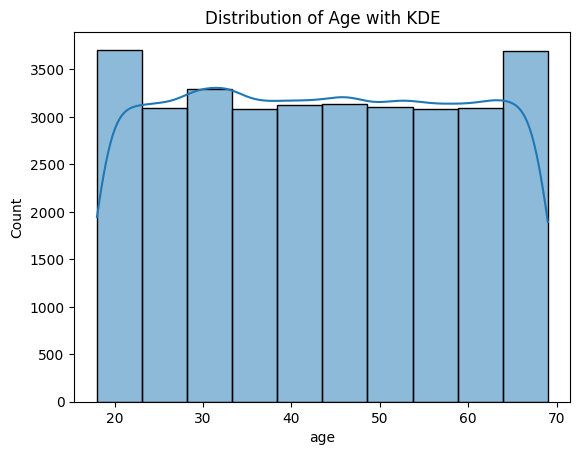

In [ ]:
sns.histplot(x='age', data=df, kde=True, bins=10)
plt.title('Distribution of Age with KDE')
plt.show()

In [ ]:
print("Monlthy Income Statistics: ")
df['monthly_income_usd'].describe()

Monlthy Income Statistics: 


,monthly_income_usd
count,32424.000000
mean,2961.057811
std,2420.841132
min,0.000000
25%,0.000000
50%,3059.825000
75%,4823.187500
max,12404.050000


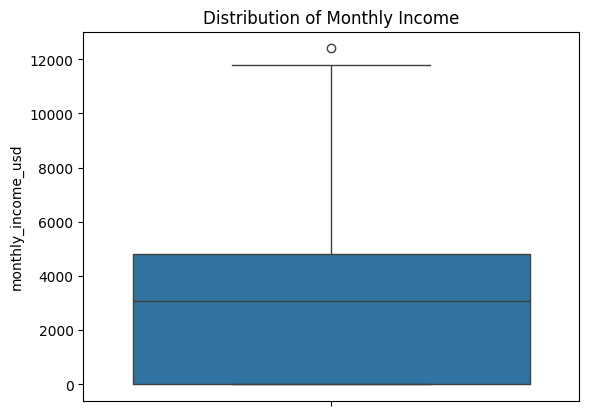

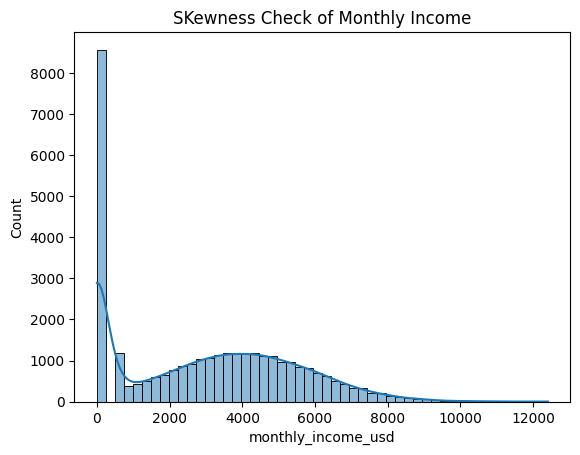

In [ ]:
sns.boxplot(y='monthly_income_usd', data=df)
plt.title('Distribution of Monthly Income')
plt.show()

sns.histplot(df['monthly_income_usd'], kde=True, bins=50)
plt.title('SKewness Check of Monthly Income')
plt.show()

In [ ]:
print("Debt to Income Ratio Statistics:")
df['debt_to_income_ratio'].describe()

Debt to Income Ratio Statistics:


KeyError: 'debt_to_income_ratio'

In [ ]:
sns.boxplot(y='debt_to_income_ratio', data=df)
plt.title('Distribution of Debt-to-Income Ratio')
plt.show()

sns.histplot(df['debt_to_income_ratio'], kde=True, bins=50)
plt.title('Skewness Check of Debt-to-Income Ratio')
plt.show()

**'gender' variable:** counts are roughly equal, this will ensure that any differences in unemployment is not a result of sample size bias and the analysis will be fair.  
A small portion of records as categorized as 'other' for gender, these will be excluded later on in the preprocessing stage.  

**'employment_status' variable:** the 'unemployed'  bar is very small, so there will be a class imbalance, this is bad for the modeling phase.  

**'education_level' variable:** Bachelor' is the largest group, so the model will be best at predicting outcomes for that group.    
The model will have less data for predicting levels of education higher than a Bachelor's degree.

**'region' variable:** records are distributed evenly acros all regions, which will allow for fair comparison of how different regions' economic environments might affect unemployment.

**'age' variable:** The highest unemployed counts are individuals that are in their early 20s/late 60s. Therefore, we cannot test the dataset as a single population, we must analyze different age groups and the challenges they face related to unemployment.


**Monthly Income**  
The typical individual has a salary of approximately \$4,000 based on the median showcased in the boxplot of 'monthly_income_usd', half of the population earns less than \$4,000 and the other half earns more.    
There are high-income outliers earning close to \$10,000 and more present in the boxplot.  
Because of these outliers, the average income will be pulled up.  

In the histplot, the highest frequency is around \$4,000, matching the median shown in the boxplot.  
There is a long extending tail, indicating it is severely right skewed towards incomes of $10,000 and more, confirming the outliers seen in the boxplot.  

The variable will require preprocessing before a predictive model can use it.

**Debt-to-Income Ratio**  
The boxplot is compressed near zero indicating that most individuals have very low debt, however, there are outliers extending up to 80+, these outliers represent individuals with extreme debt.

The majority of debt-to-income ratio values in the histplot are near zero, but it is severly skewed to the right. Indicating most people have low to no debt, while a group with extreme debt exists. This confirms the boxplot's output.

Since the variable is imbalanced, it will require a long transformation to be able to use it in any predictive model.

**Bivariate EDA**

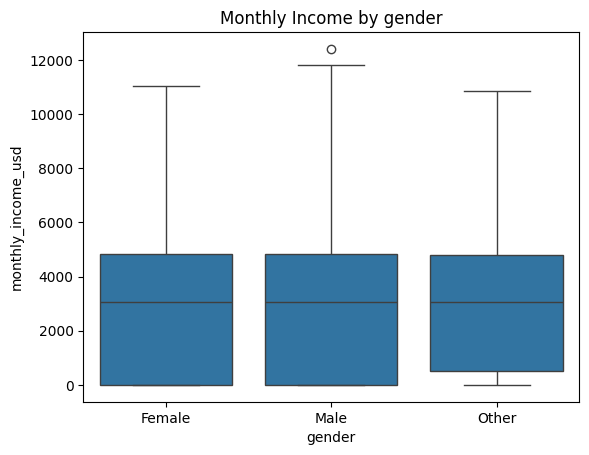

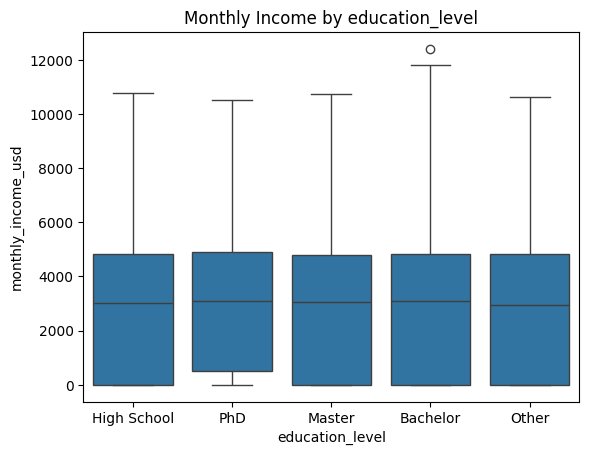

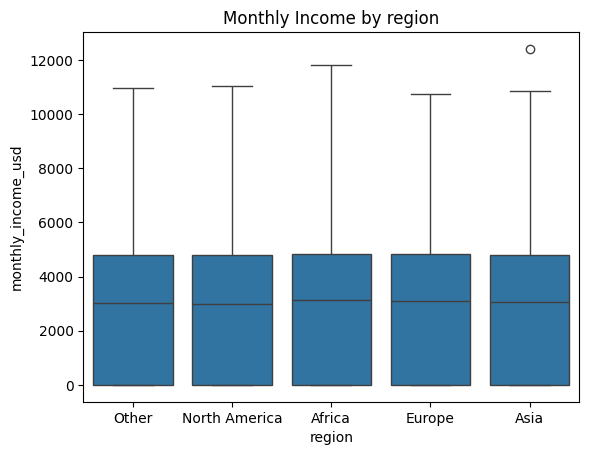

In [ ]:
cols = ['gender', 'education_level', 'region']

for col in cols:
  sns.boxplot(data=df, x=col, y='monthly_income_usd')
  plt.title(f"Monthly Income by {col}")
  plt.show()

**1. Monthly Income by Gender**  
The median income for female is visually identical to that of male. In this dataset, there is not a clear median wage gap between male and female individuals.

**2. Monthly Income by Education Level**   
The median income across all four major education levels: High School, PhD, Master and Bachelor is  nearly identical.

**3. Monthly Income by Region**  
The median income is almost identical across all five regions: North America, Africa, Europe, Asia and Other. There is no sign that different regions affect the median monthly income.

In [ ]:
# used a logs scale to spread out the high incomes to get a clearer plot

plt.scatter(np.log(df['monthly_income_usd']), df['debt_to_income_ratio'], alpha=0.4)
plt.xlabel("Log(Monthly Income)")
plt.ylabel("Debt-to-Income Ratio")
plt.title("Monthly Income vs Debt-to-Income Ratio (Log-Scaled)")
plt.show()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


KeyError: 'debt_to_income_ratio'

The log-scaled scatter plot shows a negative correlation. As monthly income increases, the debt-to-income ratio generally decreases. This is expected, as wealthier individuals typically manage their debt better that individuals with mid-to-lower income.

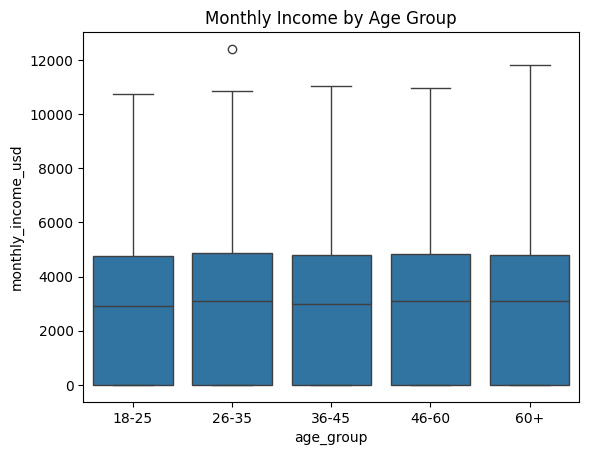

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[18,25,35,45,60,100],
                         labels=['18-25','26-35','36-45','46-60','60+'])

sns.boxplot(data=df, x='age_group', y='monthly_income_usd')
plt.title("Monthly Income by Age Group")
plt.show()

**Monthly Income by Age Group**  
The median income is the same across all age groups, from '18-25' to '60+'.  

This is an unusual. It suggests that there is no relation between age and the median income in this dataset. An 18-25 year-old is just as likely to earn the median income as a 46-60 year-old, which is not realistic.

In [ ]:
sns.boxplot(data=df, x='employment_status', y='debt_to_income_ratio')
plt.xticks(rotation=45)
plt.title("Debt-to-Income Ratio by Employment Status")
plt.show()

ValueError: Could not interpret value `debt_to_income_ratio` for `y`. An entry with this name does not appear in `data`.

While the median is zero for all employment statuses, the density and height of the outliers vary. The 'employed' and 'self-employed' groups show the largest outliers (up to 80+), meaning that individuals under the most extreme financial stress are employed. Unemployed individuals are not the ones with high debt stress, it is found in the working groups instead.

**Correlations:**  
Based on the box plots for gender, education_level, age_group, and region, there is no meaningful correlation between these variables and the median Monthly Income. This is an unusual and important finding. It suggests that factors like education, gender, and age do not determine the typical monthly income in this specific dataset. If a gender difference in income exists, it must be located within a specific, smaller group, like among outliers with high incomes.

The log-scaled scatter plot shows a negative correlation. As monthly income increases, the debt-to-income ratio generally decreases. This is expected, as wealthier individuals typically manage their debt better that individuals with mid-to-lower income.

**Outliers:**  
A significant number of income outliers are visible all boxplots (by gender, education, age, and region), often stretching up to $10,000. These are high-income earners. Their presence confirms that the income data is skewed to the right.  

There are noticable debt-to-income-ratio outliers, reaching values of 80+, while the median is near zero for all employment groups. This confirms the existence of a small group facing severe debt stress. These outliers are most dense in the 'Employed' and 'Self-employed' categories. This suggests that individuals who have access to loans, experience high debt burdens rather than being concentrated among the unemployed.

**Preprocessing and Transformation**

The following code is for data cleaning and removing the non-sense data. (The first code is checking if there's any non-sense data while the second code is cleaning it and mark them as NaN).

In [ ]:

cols_to_drop = [
    'has_loan',
    'loan_type',
    'loan_amount_usd',
    'loan_term_months',
    'monthly_emi_usd',
    'loan_interest_rate_pct',
    'debt_to_income_ratio',
    'record_date'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
df['employment_status'] = df['employment_status'].astype(str).str.lower().str.strip()
df['job_title'] = df['job_title'].apply(lambda x: x.lower().strip() if isinstance(x, str) else np.nan)

allowed_unemployed = (
    (df['employment_status'] == 'unemployed') &
    (df['job_title'] == 'unemployed')
)

mask_unemployed = (
    (df['employment_status'] == 'unemployed') &
    ~allowed_unemployed &
    (
        (df['job_title'].notna() & (df['job_title'] != "")) |
        (df['monthly_income_usd'] > 0)
    )
)

df.loc[mask_unemployed, 'job_title'] = np.nan
df.loc[mask_unemployed, 'monthly_income_usd'] = 0


mask_employed_wrong_title = (
    (df['employment_status'] == 'employed') &
    (df['job_title'] == 'unemployed')
)
df.loc[mask_employed_wrong_title, 'job_title'] = np.nan


mask_student = (df['employment_status'] == 'student')
df.loc[mask_student, 'job_title'] = "None"
df.loc[mask_student, 'monthly_income_usd'] = 0


mask_employed_but_student = (
    (df['employment_status'] == 'employed') &
    (df['job_title'] == 'student')
)


df.loc[mask_employed_but_student, 'employment_status'] = "student"
df.loc[mask_employed_but_student, 'job_title'] = "None"
df.loc[mask_employed_but_student, 'monthly_income_usd'] = 0

mask_unemp_all = (df['employment_status'] == 'unemployed')
df.loc[mask_unemp_all, 'monthly_income_usd'] = 0
df.loc[mask_unemp_all, 'monthly_expenses_usd'] = 0

In [ ]:
df_cleaned = df.dropna()
print(df_cleaned[['user_id', 'employment_status', 'job_title', 'monthly_income_usd']].head(50))
print(f"Total rows: {len(df_cleaned)}")
df_cleaned.to_csv("cleaned_dataset.csv", index=False)

   user_id employment_status    job_title  monthly_income_usd
0   U00001     self-employed  salesperson             3531.69
1   U00002          employed  salesperson             3531.73
2   U00003          employed      teacher             2799.49
3   U00004          employed      manager             5894.88
4   U00005           student         None                0.00
5   U00006           student         None                0.00
6   U00007           student         None                0.00
8   U00009     self-employed       doctor             4271.51
9   U00010           student         None                0.00
10  U00011          employed      manager             3677.43
11  U00012           student         None                0.00
12  U00013           student         None                0.00
13  U00014          employed       driver             5546.28
14  U00015          employed   accountant             3286.51
17  U00018          employed       doctor             2571.30
19  U000

**================================**

**Identify and address outliers or noise**

**Identify and address outliers**

=== IDENTIFY AND ADDRESS OUTLIERS ===
Outliers: 
monthly_income_usd: 2 outlier (0.0%)
monthly_expenses_usd: 379 outlier (1.4%)
savings_usd: 298 outlier (1.1%)
credit_score: 0 outlier (0.0%)


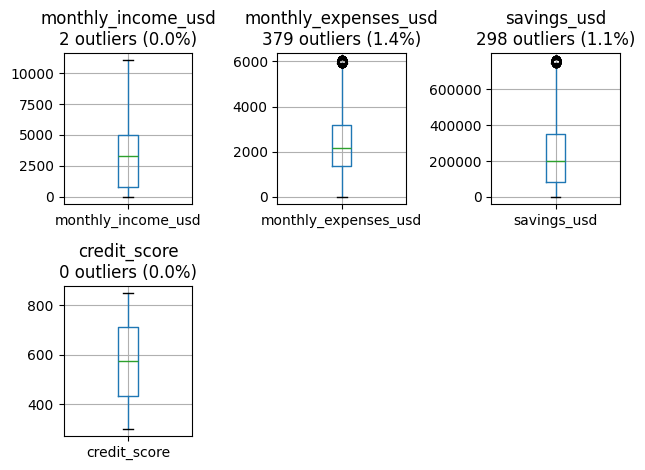

In [ ]:
#outliers
print("=== IDENTIFY AND ADDRESS OUTLIERS ===")
fin_vars=['monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'credit_score']
print("Outliers: ")
for i,var in enumerate(fin_vars):
  Q1=df_cleaned[var].quantile(0.25)
  Q3=df_cleaned[var].quantile(0.75)
  IQR=Q3-Q1
  lb=Q1-1.5*IQR
  ub=Q3+1.5*IQR
  outlier=df_cleaned[(df_cleaned[var]<lb)|(df_cleaned[var] > ub)]
  df_cleaned=df_cleaned[(df_cleaned[var]>=lb)&(df_cleaned[var]<=ub)]
  #df_cleaned = df_cleaned[~((df_cleaned[i]<(Q1-1.5*IQR))|(df_cleaned[i]>(Q3+1.5*IQR)))]
  outlier_precentage=(len(outlier)/len(df_cleaned))*100
  print(f"{var}: {len(outlier)} outlier ({outlier_precentage:.1f}%)")
  plt.subplot(2, 3, i+1)
  df_cleaned.boxplot(column=var)
  plt.title(f'{var}\n{len(outlier)} outliers ({outlier_precentage:.1f}%)')
plt.tight_layout()
plt.show()

we used boxplots to check for outliers in income, expenses, savings, and credit score

income(was the least having outliers meaning the salaries mostly have a fixed range)
but expenses, and savings had some extreme values (shown as black dots) (meaning people’s spending and saving habits vary a lot, some might spend or save way more than average creating those extreme values)
Credit score had no outliers because credit scores usually fall within a standard range

after removing them the data became cleaner and more balanced which helps improve model performance

**Apply encoding**

In [ ]:
#encoding
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
categorical_cols=df_cleaned.select_dtypes(include=['object']).columns
print(f"Categorical columns needing ENCODING: {list(categorical_cols)}")
numeric_cols=df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"Numeric columns needing SCALING: {list(numeric_cols)}")
categorical_cols=['gender', 'education_level', 'employment_status', 'job_title', 'region']
for i in categorical_cols:
    df_cleaned[i]=df_cleaned[i].astype(str).str.lower().str.strip()
le=LabelEncoder()
for i in categorical_cols:
    df_cleaned[i]=le.fit_transform(df_cleaned[i])
print(df_cleaned[categorical_cols].head())


Categorical columns needing ENCODING: ['user_id', 'gender', 'education_level', 'employment_status', 'job_title', 'region']
Numeric columns needing SCALING: ['age', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'credit_score', 'savings_to_income_ratio']
   gender  education_level  employment_status  job_title  region
0       0                1                  1          6       4
1       0                4                  0          6       3
2       0                2                  0          8       0
3       1                4                  0          4       2
4       0                4                  2          5       0


In [ ]:
#encoding
'''from pandas.core.arrays import numeric
print("Data Types:")
df_cleaned=df_cleaned.drop(columns=cols_to_drop, errors='ignore')
print(df_cleaned.dtypes.value_counts())
categorical_cols=df_cleaned.select_dtypes(include=['object']).columns
print(f"Categorical columns needing ENCODING: {list(categorical_cols)}")
numeric_cols=df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"Numeric columns needing SCALING: {list(numeric_cols)}")
for col in categorical_cols:
    print(f"\n {col}:")
    print(f"   Unique values ({df_cleaned[col].nunique()}): {df_cleaned[col].unique()}")
print("\n\n")
education_encoded={
    'High School':0,
    'Bachelor':1,
    'Master':2,
    'PhD':3,
    'Other':4
}
df_cleaned.loc[:,'education_level']=df_cleaned['education_level'].map(education_encoded)
employment_encoded={
    'employed':0,
    'unemployed':1,
    'self-employed':2,
    'student':3
}
df_cleaned.loc[:,'employment_status']=df_cleaned['employment_status'].map(employment_encoded)
job_title_encoded={
    'salesperson':1,
    'teacher':2,
    'manager':3,
    'student':4,
    'accountant':5,
    'doctor':6,
    'unemployed':7,
    'driver':8,
    'engineer':9,
 }
df_cleaned.loc[:,'job_title']=df_cleaned['job_title'].map(job_title_encoded)
gender_encoded={
    'Male':0,
    'Female':1,
    'Other':2
}
df_cleaned.loc[:,'gender']=df_cleaned['gender'].map(gender_encoded)
region_encoded={
    'Other':0,
    'North America':1,
    'Africa':2,
    'Europe':3,
    'Asia':4,
 }
df_cleaned.loc[:,'region']=df_cleaned['region'].map(region_encoded)
print(df_cleaned.head())'''


Data Types:
int64       7
float64     4
object      1
category    1
Name: count, dtype: int64
Categorical columns needing ENCODING: ['user_id']
Numeric columns needing SCALING: ['age', 'gender', 'education_level', 'employment_status', 'job_title', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'credit_score', 'savings_to_income_ratio', 'region']

 user_id:
   Unique values (25812): ['U00001' 'U00002' 'U00003' ... 'U32421' 'U32423' 'U32424']



  user_id  age  gender  education_level  employment_status  job_title  \
0  U00001   56     NaN              NaN                NaN        NaN   
1  U00002   19     NaN              NaN                NaN        NaN   
2  U00003   20     NaN              NaN                NaN        NaN   
3  U00004   25     NaN              NaN                NaN        NaN   
4  U00005   53     NaN              NaN                NaN        NaN   

   monthly_income_usd  monthly_expenses_usd  savings_usd  credit_score  \
0             3531.69    

/tmp/ipython-input-3382949613.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan nan ... nan nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cleaned.loc[:,'education_level']=df_cleaned['education_level'].map(education_encoded)
/tmp/ipython-input-3382949613.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan nan ... nan nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cleaned.loc[:,'employment_status']=df_cleaned['employment_status'].map(employment_encoded)
/tmp/ipython-input-3382949613.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan nan ... nan nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype f

So my dataset has different kinds of columns some are categories like gender (which can be Female, Male, or Other) education level (like High School, Bachelor) and region (like Asia or Europe) these categorical columns have words but models don’t understand words well so I need to turn them into numbers

**scaling, and discretization if needed**

Numeric columns needing SCALING: ['age', 'gender', 'education_level', 'employment_status', 'job_title', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'credit_score', 'savings_to_income_ratio', 'region']
BEFORE SCALING STATISTICS:
   monthly_income_usd: min=0.00, max=10515.08, mean=3103.76


   monthly_expenses_usd: min=0.00, max=6055.58, mean=2311.65


   savings_usd: min=635.96, max=761547.59, mean=233846.61


   credit_score: min=300.00, max=850.00, mean=574.31


   savings_to_income_ratio: min=0.10, max=10.00, mean=5.01


AFTER SCALING STATISTICS:
   monthly_income_usd: mean=-0.00, std=1.00


   monthly_expenses_usd: mean=0.00, std=1.00


   savings_usd: mean=-0.00, std=1.00


   credit_score: mean=-0.00, std=1.00


   savings_to_income_ratio: mean=0.00, std=1.00




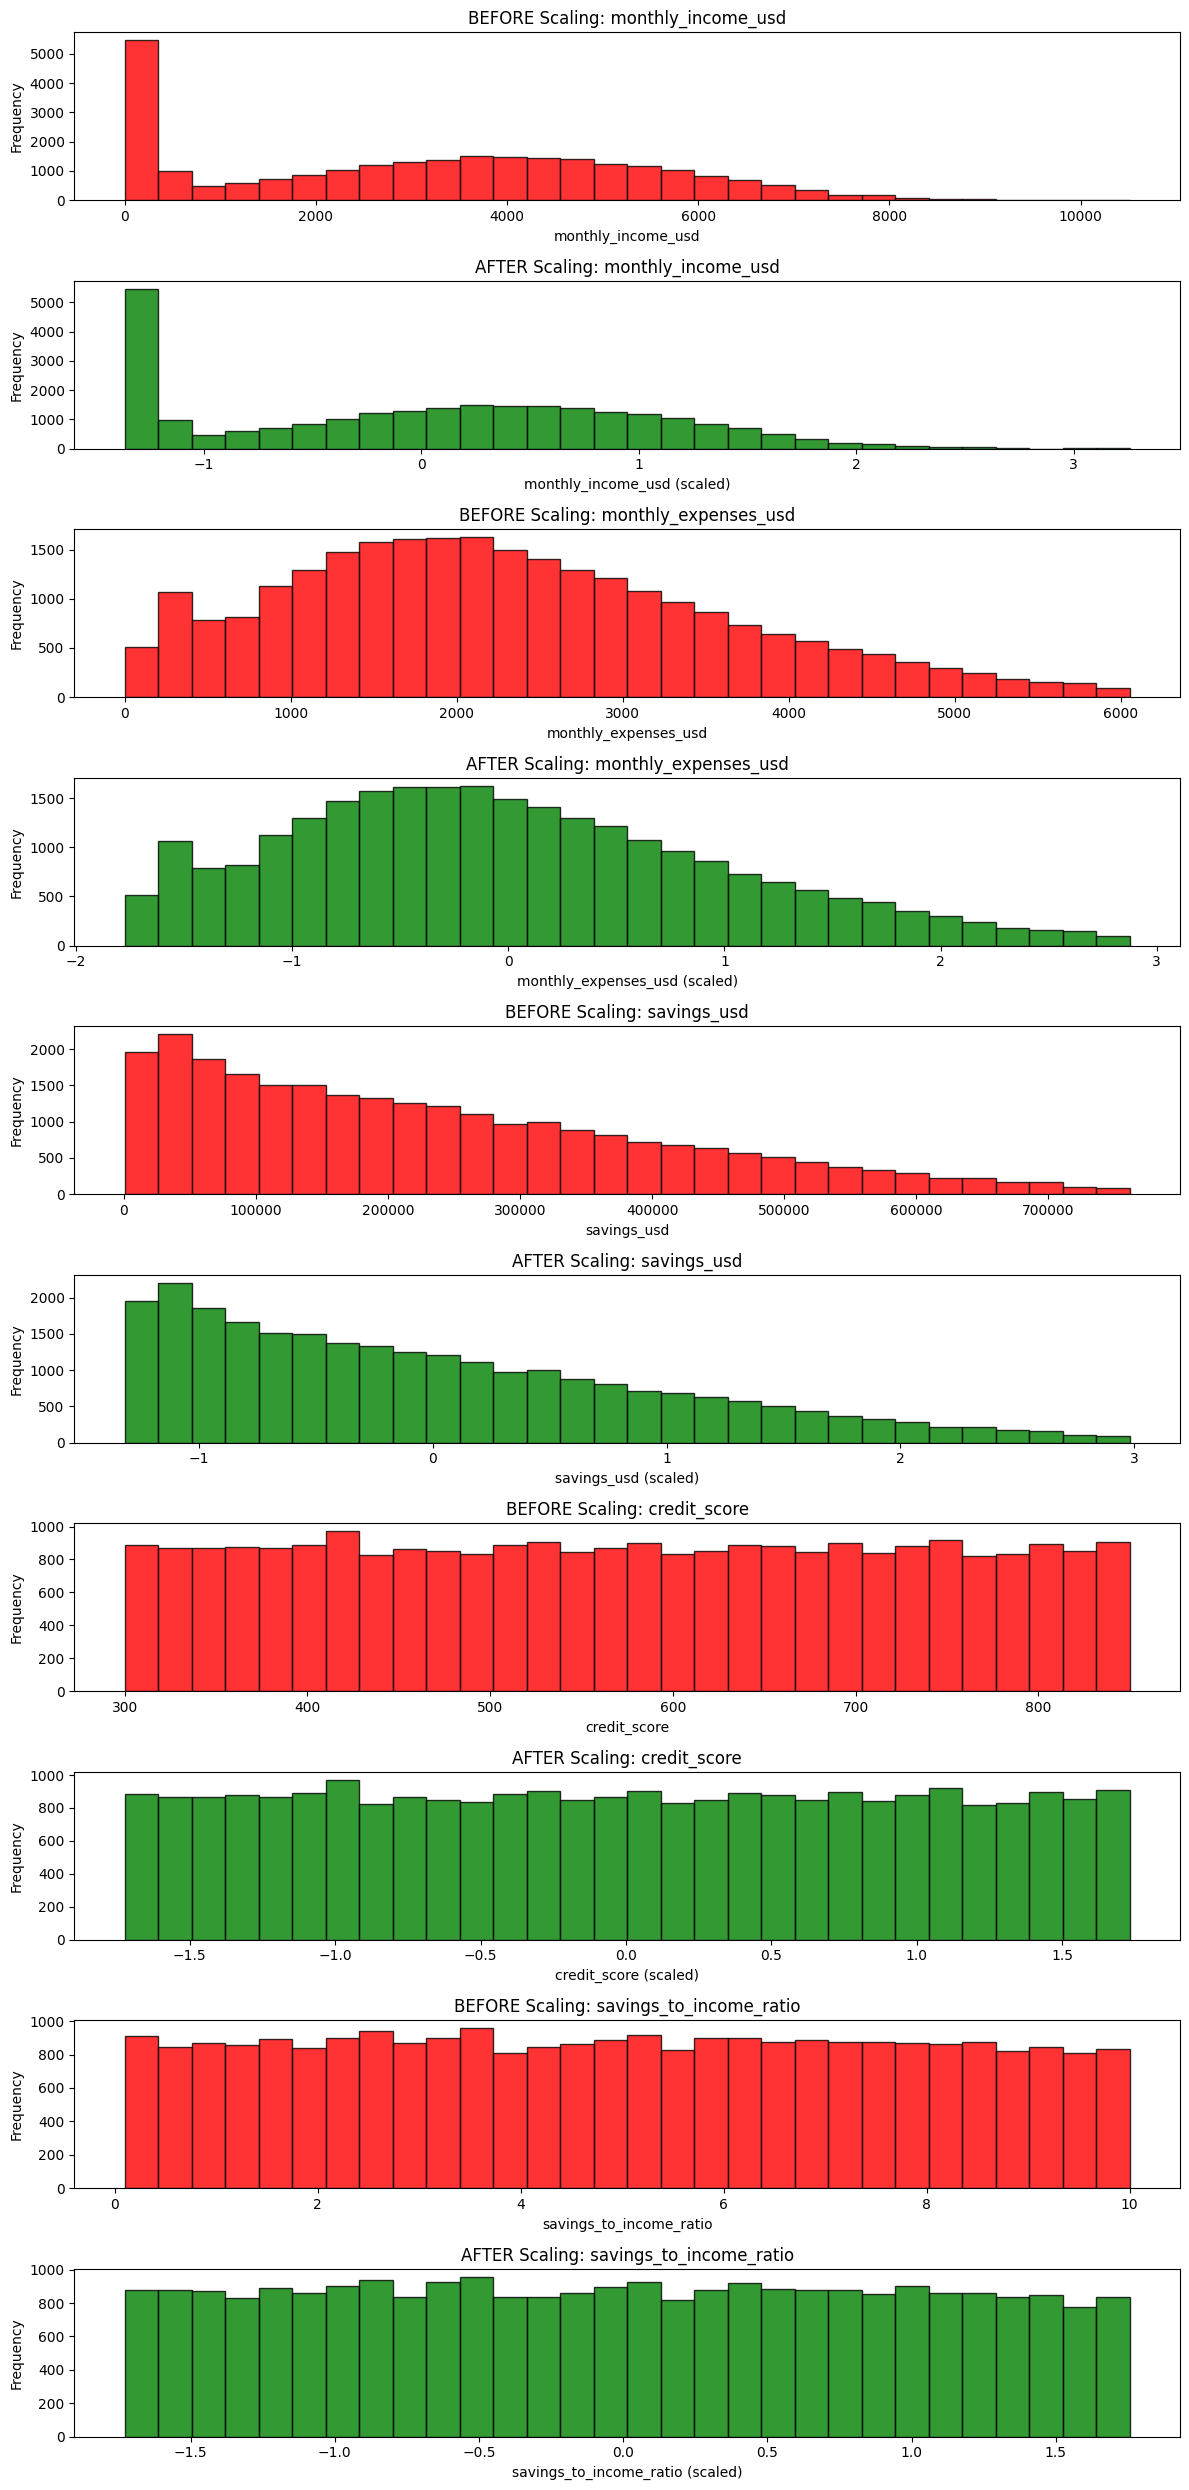

In [ ]:
#scaling
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
numeric_cols=df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"Numeric columns needing SCALING: {list(numeric_cols)}")
scaling_cols=[i for i in numeric_cols if i not in ['user_id','region','age', 'gender', 'education_level', 'employment_status', 'job_title',]]
print("BEFORE SCALING STATISTICS:")
for i in scaling_cols:
  if i in df.columns:
    print(f"   {i}: min={df_cleaned[i].min():.2f}, max={df_cleaned[i].max():.2f}, mean={df_cleaned[i].mean():.2f}")
    print("\n")
scaler=MinMaxScaler()
df_scaled=df_cleaned.copy()
scaler=StandardScaler()
df_scaled[numeric_cols]=scaler.fit_transform(df_scaled[numeric_cols])
print("AFTER SCALING STATISTICS:")
for i in scaling_cols:
  if i in df_scaled.columns:
    print(f"   {i}: mean={df_scaled[i].mean():.2f}, std={df_scaled[i].std():.2f}")
    print("\n")
print("======================================")
n_cols=1
n_rows=len(scaling_cols)*2
plt.figure(figsize=(12,5*len(scaling_cols)))
plot_index=1
for col in scaling_cols:
    plt.subplot(n_rows, n_cols, plot_index)
    plt.hist(df_cleaned[col], bins=30, alpha=0.8, edgecolor='black', color='red')
    plt.title(f'BEFORE Scaling: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plot_index+=1
    plt.subplot(n_rows, n_cols, plot_index)
    plt.hist(df_scaled[col], bins=30, alpha=0.8, edgecolor='black', color='green')
    plt.title(f'AFTER Scaling: {col}')
    plt.xlabel(col + " (scaled)")
    plt.ylabel('Frequency')
    plot_index += 1
plt.tight_layout()
plt.show()

before scaling:  
for example, the credit scores look like normal numbers between 300 and 850 which can be hard for some models and may cause bias after scaling (this can confuse some models because they work better when numbers are on the same scale)

after scaling:  
all these columns have a mean close to 0(in the output it says -0.0 means zero but with tiny rounding ) and a standard deviation of 1 this means the data is now centered and spread evenly it helps models learn better and faster because the features are balanced and easier to compare

plots:  
the scores are transformed to a smaller centered range around -1.5 to 1.5 the shape stays the same(it may be silghtly different) but now the numbers are easier for some models to work with

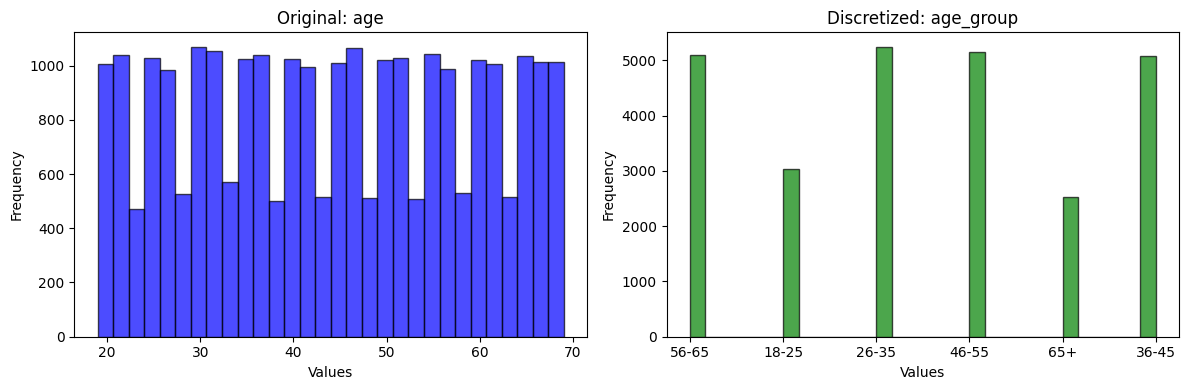

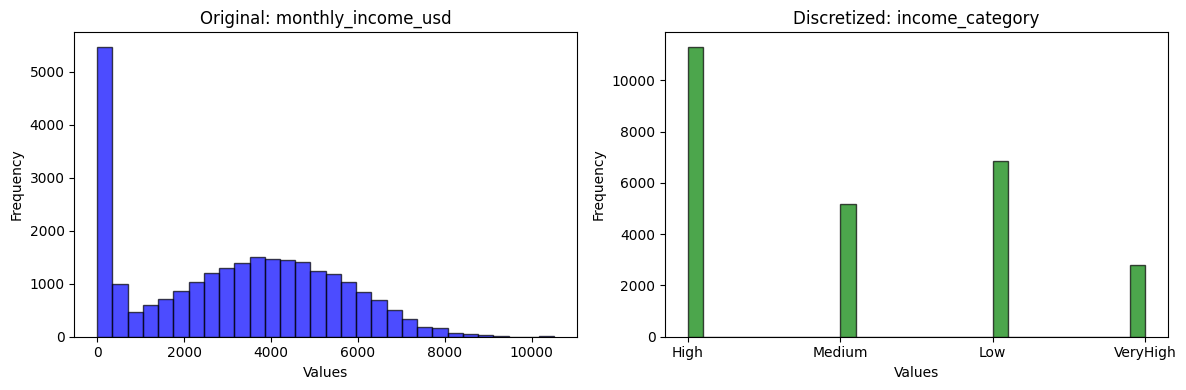

In [ ]:
#APPLYING DISCRETIZATION
df_discrete=df_cleaned.copy()
age_bins=[0, 25, 35, 45, 55, 65, 100]
age_labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_discrete['age_group']=pd.cut(df_discrete['age'], bins=age_bins, labels=age_labels, right=False)
income_bins=[0, 1000, 3000, 6000, 15000]
income_labels=['Low','Medium','High','VeryHigh']
df_discrete['income_category'] = pd.cut(df_discrete['monthly_income_usd'],bins=income_bins,
  labels=income_labels,
  include_lowest=True
)
comparison_pairs=[
    ('age', 'age_group'),('monthly_income_usd', 'income_category'),]
for continuous_col, discrete_col in comparison_pairs:
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.hist(df_discrete[continuous_col], bins=30, alpha=0.7, color='blue', edgecolor='black')
  plt.title(f'Original: {continuous_col}')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  plt.subplot(1, 2, 2)
  plt.hist(df_discrete[discrete_col], bins=30, alpha=0.7, color='green', edgecolor='black')
  plt.title(f'Discretized: {discrete_col}')
  plt.xlabel('Values')
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

first the plots show the original data for age and monthly income The age data looks lind of spread out smoothly while the monthly income has many small values and a few big ones
we see the discretized data for age, it’s grouped into categories like "18-25", "26-35", etc, so instead of exact numbers we have age groups for income the numbers are divided into categories like "Low", "Medium", "High", and "Very High"
it helps to simplify data and make it more balanced by turning continuous values into groups which can be easier for some models to understand

In [ ]:
#STANDARDIZING FORMATS
df_standardized=df_cleaned.copy()
categorical_cols=df_standardized.select_dtypes(include=['object']).columns
print(f"Categorical columns needing STANDARDIZATION: {list(categorical_cols)}")
for i in categorical_cols:
    if i in df_standardized.columns:
        unique_vals=df_standardized[i].unique()
        print(f"\n{i}:{len(unique_vals)} unique values")
        print(f"   Values: {list(unique_vals)}")
for i in categorical_cols:
    if i in df_standardized.columns:
        df_standardized[i]=df_standardized[i].astype(str)
        df_standardized[i]=df_standardized[i].str.lower().str.strip()
        unique_vals=df_standardized[i].unique()
        print(f"\n{i}: {len(unique_vals)} unique values")
        print(f"   Values: {list(unique_vals)}")

Categorical columns needing STANDARDIZATION: ['user_id']

user_id:26155 unique values
   Values: ['U00001', 'U00002', 'U00003', 'U00004', 'U00005', 'U00006', 'U00007', 'U00009', 'U00010', 'U00011', 'U00012', 'U00013', 'U00014', 'U00015', 'U00018', 'U00020', 'U00022', 'U00023', 'U00024', 'U00025', 'U00027', 'U00029', 'U00031', 'U00034', 'U00035', 'U00037', 'U00038', 'U00039', 'U00041', 'U00043', 'U00044', 'U00045', 'U00047', 'U00049', 'U00051', 'U00052', 'U00053', 'U00056', 'U00058', 'U00059', 'U00060', 'U00061', 'U00062', 'U00063', 'U00064', 'U00065', 'U00066', 'U00067', 'U00068', 'U00069', 'U00070', 'U00071', 'U00072', 'U00073', 'U00074', 'U00076', 'U00077', 'U00078', 'U00081', 'U00082', 'U00083', 'U00085', 'U00086', 'U00087', 'U00088', 'U00089', 'U00090', 'U00091', 'U00092', 'U00093', 'U00094', 'U00095', 'U00096', 'U00097', 'U00098', 'U00100', 'U00102', 'U00103', 'U00104', 'U00105', 'U00106', 'U00107', 'U00108', 'U00109', 'U00110', 'U00111', 'U00113', 'U00114', 'U00115', 'U00116', 'U

so here i just cleaned up all the text columns i made everything lowercase and removed extra spaces like 'U00001' became 'u00001' that way all the categories are consistent and ready for encoding the numbers from before (like gender or education) don’t change here because they’re already numbers only the text stuff got standardized

In [ ]:
print(df_cleaned[['user_id', 'employment_status', 'job_title', 'monthly_income_usd']].head(50))

   user_id  employment_status  job_title  monthly_income_usd
0   U00001                  1          6             3531.69
1   U00002                  0          6             3531.73
2   U00003                  0          8             2799.49
3   U00004                  0          4             5894.88
4   U00005                  2          5                0.00
5   U00006                  2          5                0.00
6   U00007                  2          5                0.00
8   U00009                  1          1             4271.51
9   U00010                  2          5                0.00
10  U00011                  0          4             3677.43
11  U00012                  2          5                0.00
12  U00013                  2          5                0.00
13  U00014                  0          2             5546.28
14  U00015                  0          0             3286.51
17  U00018                  0          1             2571.30
19  U00020              

**Data Readiness Check**

**Confirm that the dataset is clean and analysis-ready**

In [ ]:
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

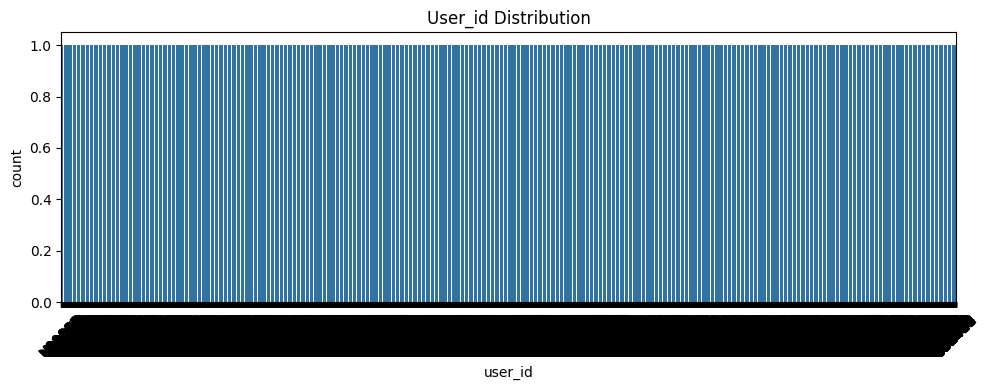

In [271]:
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=df_cleaned)
    plt.title(f"{col.capitalize()} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [274]:
missing = df_cleaned.isna().sum()
print("Missing Values per Column:")
print(missing)
print("Total Missing:", missing.sum())

duplicates = df_cleaned.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

print("Data Types:")
print(df_cleaned.dtypes)

print("Numeric Summary:")
print(df_cleaned.describe())

categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
print("Categorical Columns and Unique Values:")
for col in categorical_cols:
    print(f"\n{col}: {df_cleaned[col].unique()[:10]} ... (total: {df_cleaned[col].nunique()})")

if missing.sum() == 0 and duplicates == 0:
    print("Dataset is clean and analysis-ready.")
else:
    print("Dataset is not fully clean")
    if missing.sum() > 0:
        print(f"Missing values: {missing.sum()} total")
    if duplicates > 0:
        print(f"Duplicate rows: {duplicates}")

Missing Values per Column:
user_id                    0
age                        0
gender                     0
education_level            0
employment_status          0
job_title                  0
monthly_income_usd         0
monthly_expenses_usd       0
savings_usd                0
credit_score               0
savings_to_income_ratio    0
region                     0
age_group                  0
dtype: int64
Total Missing: 0
Duplicate Rows: 0
Data Types:
user_id                      object
age                           int64
gender                        int64
education_level               int64
employment_status             int64
job_title                     int64
monthly_income_usd          float64
monthly_expenses_usd        float64
savings_usd                 float64
credit_score                  int64
savings_to_income_ratio     float64
region                        int64
age_group                  category
dtype: object
Numeric Summary:
                age        gender  ed

To confirm that the dataset is clean and ready for analysis, I checked for any missing values, duplicate rows, data type issues, and unusual values in both numeric and categorical columns. It show whether there are any duplicated records and shows the summary. t also lists the unique values in each categorical column to make sure the categories look correct. f no missing values or duplicates appear then the dataset is ready


i checked everything and there are zero missing values which is amazing for a real dataset with 23,757 records all the data types make sense too: numbers are stored as numbers categories are properly encoded and the user_id is correctly labeled as text

the only thing that caught my eye was the huge range in money ralated stuff like savings some people have $600  while others have $760,000 But that's probably real just shows we have both students and wealthy people in the data

**Visualize transformed features or distributions after cleaning**

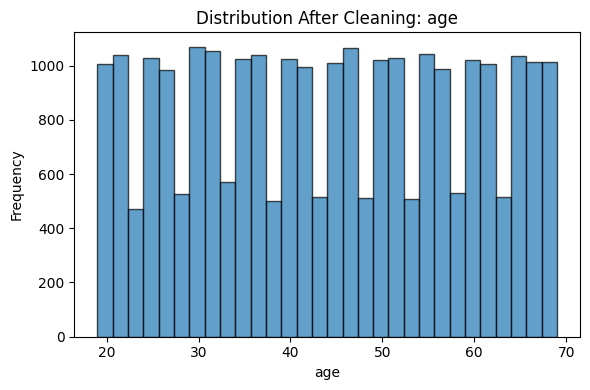

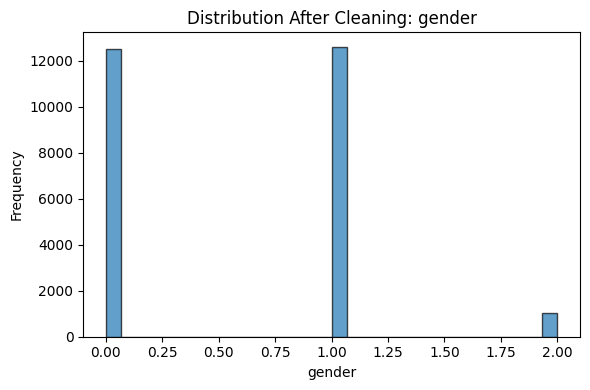

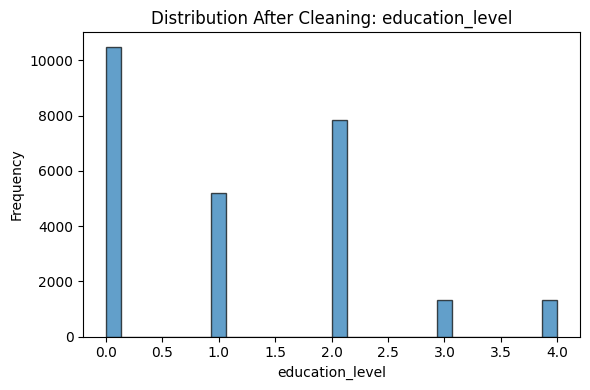

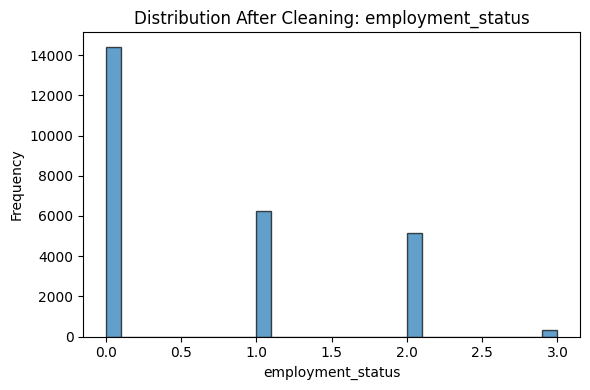

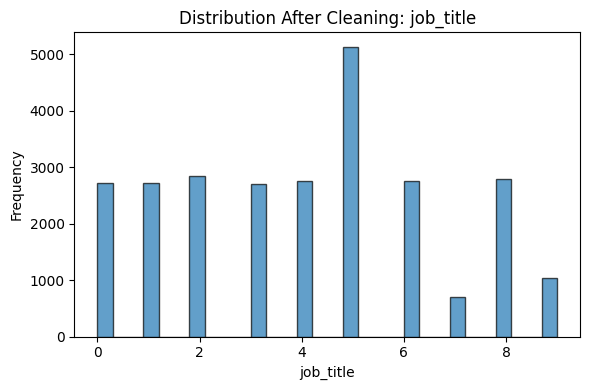

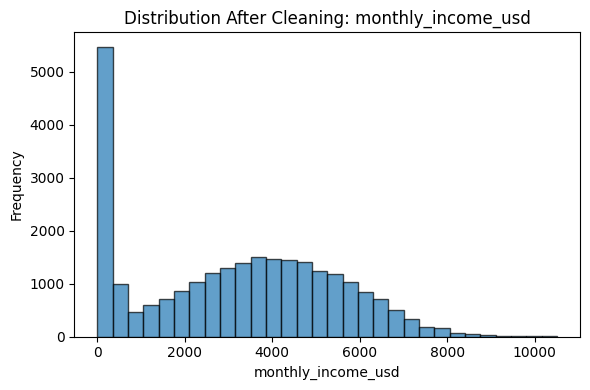

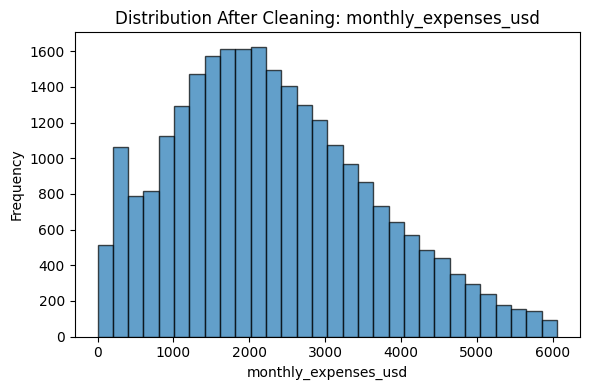

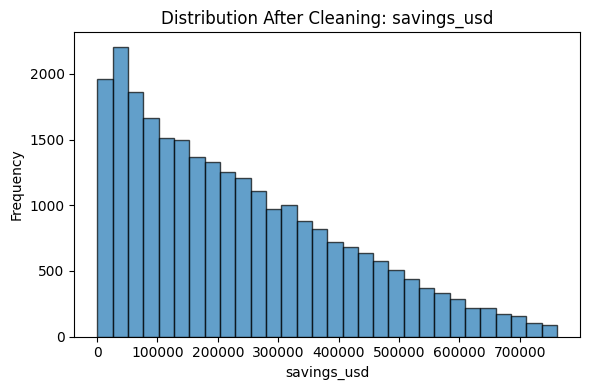

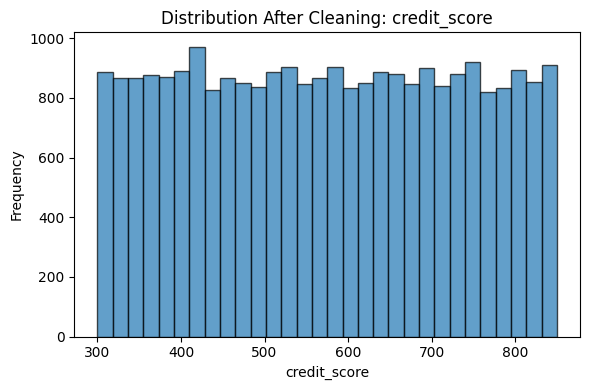

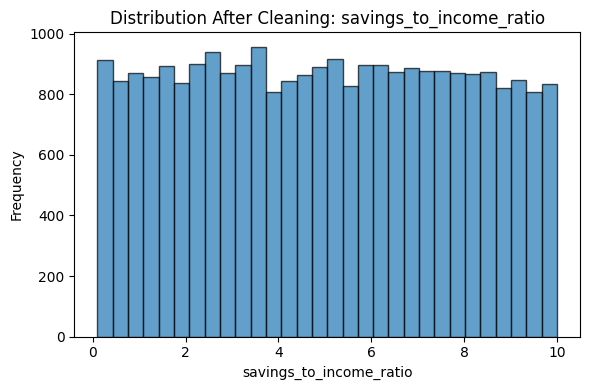

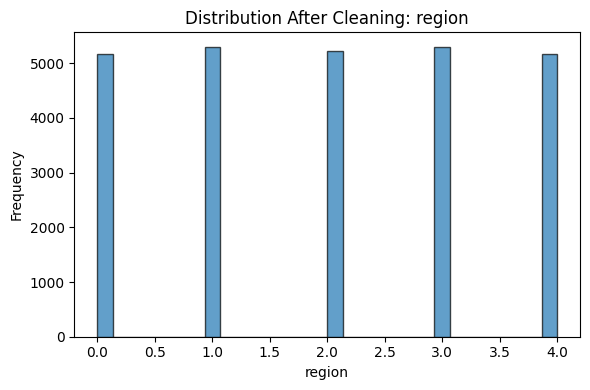

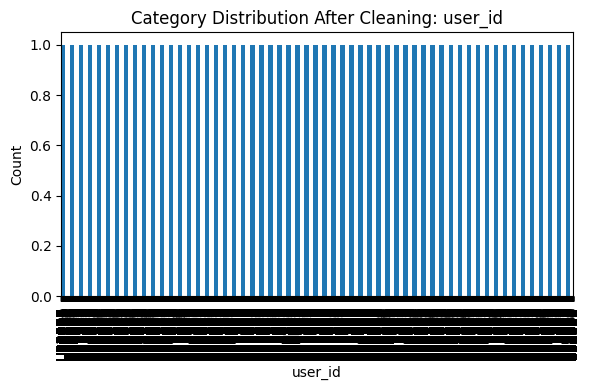

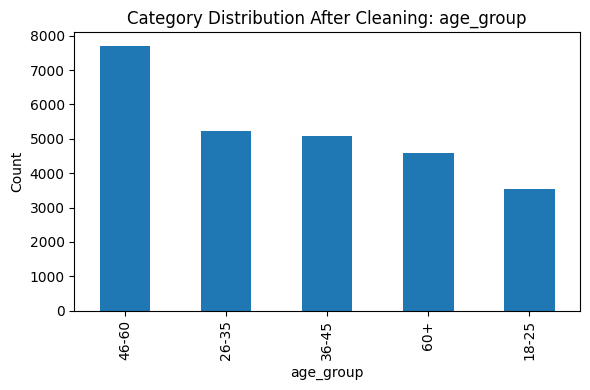

In [275]:
numeric_cols = df_cleaned.select_dtypes(include=['int64','float64']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object','category']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df_cleaned[col], bins=30, edgecolor='black', alpha=0.7)
    plt.title(f"Distribution After Cleaning: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df_cleaned[col].value_counts().plot(kind='bar')
    plt.title(f"Category Distribution After Cleaning: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

From the plots, I noticed that some of my features are balanced, while others are clearly unbalanced or right-skewed. This actually makes sense based on the nature of the data. For example, income-related variables are expected to be skewed because some groups naturally earn more than others. On the other hand, features like region and age groups show more balanced distributions, which makes sense since these categories usually have similar representation in the dataset. Overall, the patterns I saw in the visualizations match real-world expectations, so the distributions are reasonable

**Challenges and Limitations**

One limitation I still have is that the dataset is now much smaller after removing many columns so i might have lost some potentially useful information also, even though the data is clean some features still have uneven distributions which could affect model performance another challenge is that the encoded categorical variables may not fully capture the relationships in the original text labels

Overall, the data is ready, but these issues are still something I need to keep in mind during modeling

We faced a few challenges and limitations during the process. Here are some of them:
* Some students had job titles assigned which didn’t make sense. So these were replaced with None
* Several unemployed records had monthly income and expenses recorded, so both values were set to 0
* Several unemployed records had a job titl. These were cleared to keep the data consistent



**Summarize key EDA and preprocessing steps performed**



**EDA**:

1. Checked number of rowns and columns, verified data types.

2. Looked at the distribution of gender, employment status, region and education level by using count plots to see how balanced each feature was.

3. Used histograms, boxplots and KDE plots to look at the distribution of income, expenses, savings, debt-to-income ratio and age.



**preprocessing**:

1.removed Outliers from income, expenses and savings to reduce noise

2.Encoding: Categorical variables (gender, education, employment, job title, region) were converted to numbers

3.Scaled Numerical Features using StandardScaler so models don’t get biased by big numbers

4.Discretization: Age and income were grouped into categories (easier for me to analyis)

5.Standardization of Formats:to ensure consistency

**Explain how data quality has improved**

We had a big problem with the dataset itself. It contained some nonsense data like a student who worked as a doctor, or an unemployed individual who earned more than an employed doctor. A 19 year old individual with an education level of PhD, etc.

We cleaned the data by assigning students 'none' as a job title. We alos removed uneccessary rows.
After we did that, the data was clearer and ready to be dealt with.

 then removing outliers helped making the data balanced and easier to work with

encoding helps converting Categorical features to numeric values which helps models work better  
Scaling: All numeric columns were standardized for better comparison
Discretization: Age and income were grouped into categories for easier analysis
Standardization: Text values were cleaned for consistency
Result: The dataset is now clean, consistent, and ready for modeling

**List next steps for modeling (classification or clustering in P3)**

Choose Model:Try classifiers like Random Forest, Decision Tree, or KNN, or clustering methods like K-Means

Decide Goal: Predict a class (classification) or find groups (clustering).   
Split Data: Training and testing sets.   

Train and Evaluate:fit the model check accuracy, F1-score, or clustering metrics

Visualize and Interpret:plot feature importance, decision boundaries, or clusters to understand patterns

